In [7]:
import numpy as np
from sklearn.datasets import load_breast_cancer

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X, y = load_breast_cancer(return_X_y=True)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

In [11]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=100,
                           learning_rate=0.1    )
model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [12]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, preds)
print(acc)

0.9590643274853801


In [14]:
from matplotlib import pyplot as plt

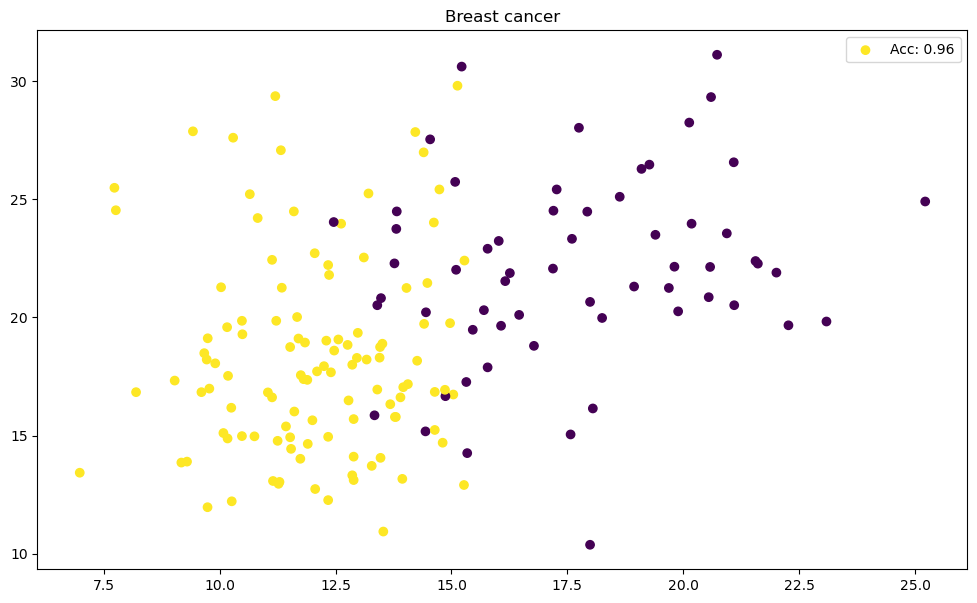

In [15]:
plt.figure(figsize=(12, 7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=preds, cmap='viridis', label=f"Acc: {acc:.2f}")
plt.title('Breast cancer')
plt.legend()   
plt.show()

In [16]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=20)
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
print(acc)  

0.9649122807017544


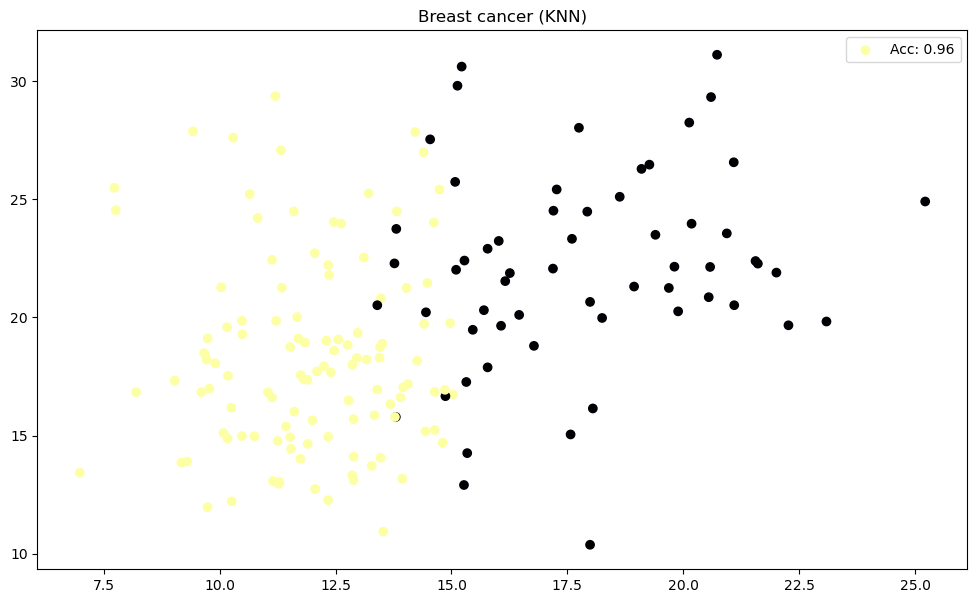

In [17]:
plt.figure(figsize=(12, 7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=preds, cmap='inferno', label=f"Acc: {acc:.2f}")
plt.title('Breast cancer (KNN)')
plt.legend()   
plt.show()

In [18]:
model.predict_proba(X_test)[:5]
probs = model.predict_proba(X_test)

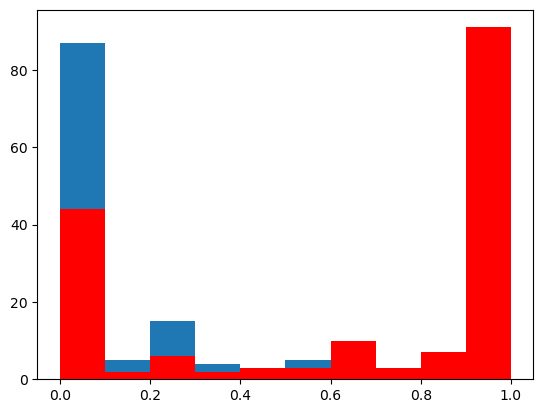

In [19]:
plt.hist(probs[:, 0]);
plt.hist(probs[:, 1], color='red');

import seaborn as sns

In [20]:
from sklearn.metrics import precision_recall_fscore_support

preds = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.001, 0.999, num=100)
precs = []
fs = []
sups = []
recalls = []

for t in thresholds:
    prec, rec, f1, support = precision_recall_fscore_support(
        y_test,
        1 * (preds > t),   
    )
    precs.append(prec[1])
    recalls.append(rec[1])
    fs.append(f1[1])
    sups.append(support[1])

precisions = np.asarray(precs)
recalls = np.asarray(recalls)

precisions, recalls

(array([0.8       , 0.8       , 0.8       , 0.8       , 0.8       ,
        0.8503937 , 0.8503937 , 0.8503937 , 0.8503937 , 0.8503937 ,
        0.85714286, 0.85714286, 0.85714286, 0.85714286, 0.85714286,
        0.864     , 0.864     , 0.864     , 0.864     , 0.864     ,
        0.87096774, 0.87096774, 0.87096774, 0.87096774, 0.87096774,
        0.87804878, 0.87804878, 0.87804878, 0.87804878, 0.87804878,
        0.90756303, 0.90756303, 0.90756303, 0.90756303, 0.90756303,
        0.92307692, 0.92307692, 0.92307692, 0.92307692, 0.92307692,
        0.93913043, 0.93913043, 0.93913043, 0.93913043, 0.93913043,
        0.93859649, 0.93859649, 0.93859649, 0.93859649, 0.93859649,
        0.95535714, 0.95535714, 0.95535714, 0.95535714, 0.95535714,
        0.95535714, 0.95535714, 0.95535714, 0.95535714, 0.95535714,
        0.96396396, 0.96396396, 0.96396396, 0.96396396, 0.96396396,
        0.97196262, 0.97196262, 0.97196262, 0.97196262, 0.97196262,
        0.99009901, 0.99009901, 0.99009901, 0.99

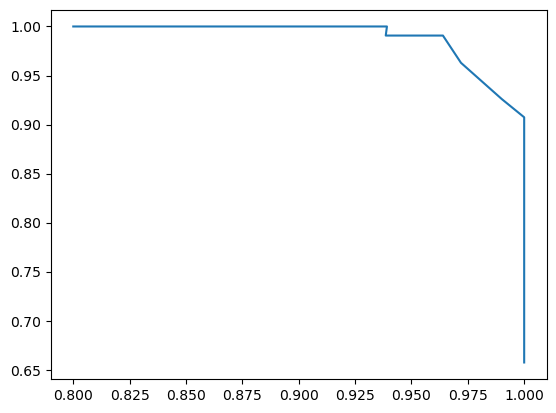

In [21]:
plt.plot(precisions, recalls)

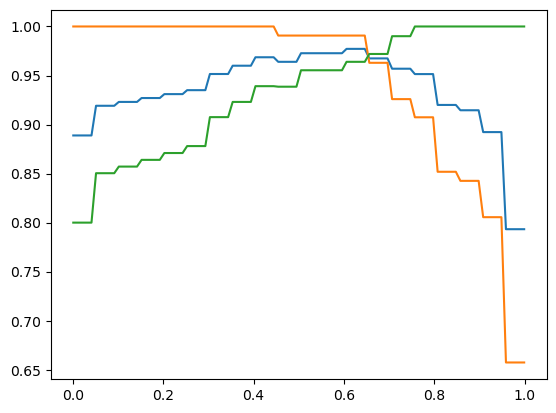

In [22]:
plt.plot(thresholds, fs);
plt.plot(thresholds, recalls);
plt.plot(thresholds, precisions);
# plt.plot(thresholds, sups)

In [23]:
from sklearn.metrics import average_precision_score

from sklearn.metrics import top_k_accuracy_score

# average_precision_score(y_true=y_test, y_score=preds, average='macro')

from sklearn.metrics import roc_auc_score
roc_auc_score(y_true=y_test, y_score=preds)

# top_k_accuracy_score(y_true=y_test, y_score=preds, k=3) 

0.9961052322163432

In [24]:
from sklearn.svm import SVC

model = SVC()
model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
acc

roc_auc_score(y_test, preds)

0.9126984126984127